# Étape 4 : Optimisation hyperparamètres + seuil métier

optimiser LightGBM via Optuna en minimisant la métrique métier puis ajuster le seuil de décision optimal

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import lightgbm as lgb
import optuna
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from sklearn.utils import resample
import re
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('credit_scoring_v4')

<Experiment: artifact_location='file:///c:/Users/axell/Documents/projets_code/projet_6/projet6/mlruns/6', creation_time=1773941796882, experiment_id='6', last_update_time=1773941796882, lifecycle_stage='active', name='credit_scoring_v4', tags={}, workspace='default'>

On recharge train_final.csv et on refait le même split 80/20 qu'à l'étape 3 avec les mêmes paramètres pour travailler sur les mêmes données.


In [11]:
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

train = pd.read_csv('train_final.csv')
X = clean_col_names(train.drop(columns=['TARGET', 'SK_ID_CURR']))
y = train['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')

X_train : (246008, 581) | X_test : (61503, 581)


## Métrique métier + seuil optimal
on redéfinit error_cost et optimal_threshold, les mêmes fonctions qu'à l'étape 3.

- Un FN coûte 10x plus qu'un FP
- `optimal_threshold` teste 100 seuils et retourne celui qui minimise ce coût

Pour traduire le déséquilibre du coût business = rater un client qui ne rembourse pas (faux négatif) coûte 10x plus cher que refuser un client qui aurait remboursé (faux positif).

- error_cost : Le modèle ne prédit pas directement "rembourse" ou "rembourse pas" mais une probabilité entre 0 et 1. Par exemple : "ce client a 73% de chances d'être de ne pas rembourser". Pour transformer cette probabilité en décision, il faut un seuil : si proba >= seuil, alors on prédit que le client ne remboursera pas. On compte deux types d'erreurs : FN et FP. Si FN, ça coûte 10, car plus grave, et si FP, ça coûte 1.

- Faux négatif = on a accordé un crédit à quelqu'un qui ne remboursera pas
- Faux positif = on a refusé un crédit à quelqu'un qui aurait remboursé

#### Choix du seuil/threshold

- optimal_threshold : Le seuil par défaut de 0.5 n'est pas forcément le meilleur. Avec un faux négatif (accorder un crédit à qqn qui ne remboursera pas) qui coûte 10x plus qu'un FP il faut être plus sévère = baisser le seuil pour refuser plus de clients dans le doute, même si on rate qq bons clients au passage. Donc on génère des seuils à tester et pour chacun on calcule le coût total. Le meilleur est celui qui retourne le coût le plus bas.
- Seuil trop bas (0.01) = on refuse tout le monde = beaucoup de FP = coût élevé
- Seuil trop haut (0.99) = on accepte tout le monde = beaucoup de FN = coût très élevé

In [12]:
def error_cost(y_true, y_proba, threshold=0.5, cost_fn=10, cost_fp=1):
    """
    Calcule le coût total des erreurs pour un seuil donné.
    """
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()

    return cost_fn * fn + cost_fp * fp

def optimal_threshold(y_true, y_proba):
    """
    Teste 100 seuils et retourne celui qui coûte le moins cher
    """
    thresholds = np.linspace(0.01, 0.99, 100)
    costs = [error_cost(y_true, y_proba, t) for t in thresholds]
    best_t = thresholds[np.argmin(costs)]
    return best_t, min(costs)

## Optimisation (Optuna)

- résulat moins bons avec gridsearch
- Optuna sur un échantillon de 100.000 clients 
    - fonction `objective` appelée à chaque essai : entraîne un modèle avec les hyperparams suggérés et retourne le coût métier moyen sur 3 folds
- modèle final ensuite réentraîné sur tout X_train avec les meilleurs hyperparamètres trouvés

 Optuna optimise directement sur la métrique métier (10×FN + 1×FP),
pas sur l'AUC ni l'accuracy. L'AUC est calculée en complément pour
la comparaison des modèles.

On crée un sous-échantillon de 100k clients pour limiter le temps de calcul, puis on lance Optuna qui teste différentes combinaisons d'hyperparamètres en apprenant au fil des essais. À chaque essai il entraîne un LightGBM, calcule le coût métier moyen sur 3 folds, et cherche à le minimiser. Après 15 minutes il retourne les meilleurs hyperparamètres trouvés.

In [13]:
X_sample, y_sample = resample(X_train, y_train, n_samples=100000, stratify=y_train, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight' : 'balanced',
        'random_state': 42,
        'n_jobs' : -1,
        'verbose' : -1,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    costs = []
    for tr_idx, val_idx in skf.split(X_sample, y_sample):
        X_tr, X_val = X_sample.iloc[tr_idx], X_sample.iloc[val_idx]
        y_tr, y_val = y_sample.iloc[tr_idx], y_sample.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        val_proba = model.predict_proba(X_val)[:, 1]
        _, cost = optimal_threshold(y_val, val_proba)
        costs.append(cost)
    return np.mean(costs)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=900, show_progress_bar=True)

print(f'Meilleurs hyperparametres: {study.best_params}')
print(f'Meilleur coût moyen: {study.best_value:.0f}')

Best trial: 11. Best value: 14438.3:  24%|██▍       | 12/50 [16:33<52:26, 82.81s/it, 993.68/900 seconds] 

Meilleurs hyperparametres: {'n_estimators': 595, 'learning_rate': 0.01438755502276314, 'num_leaves': 92, 'min_child_samples': 41, 'subsample': 0.8701374226690396, 'colsample_bytree': 0.602998643103704}
Meilleur coût moyen: 14438


## réentraînement sur tout X_train

On prend les meilleurs hyperparamètres trouvés par Optuna et on réentraîne le modèle sur tout X_train (pas juste les 100k), puis on l'évalue sur X_test.

In [14]:
best_model = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
best_model.fit(X_train, y_train)

test_proba = best_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, test_proba)
best_t, cost = optimal_threshold(y_test, test_proba)
y_pred_opt = (test_proba >= best_t).astype(int)
recall = recall_score(y_test, y_pred_opt, pos_label=1)
f1 = f1_score(y_test, y_pred_opt, pos_label=1)

print(f'AUC test : {auc_test:.4f}')
print(f'Coût métier : {cost:.0f}')
print(f'Seuil optimal: {best_t:.2f}')
print(f'Recall minoritaire: {recall:.4f}')
print(f'F1 minoritaire: {f1:.4f}')

AUC test : 0.7884
Coût métier : 29734
Seuil optimal: 0.50
Recall minoritaire: 0.6695
F1 minoritaire: 0.3076


## Courbe coût vs seuil
- on visualise le coût métier pour chaque seuil entre 0.01 et 0.99 pour justifier le choix du seuil optimal plutôt que de garder 0.5 par défaut.

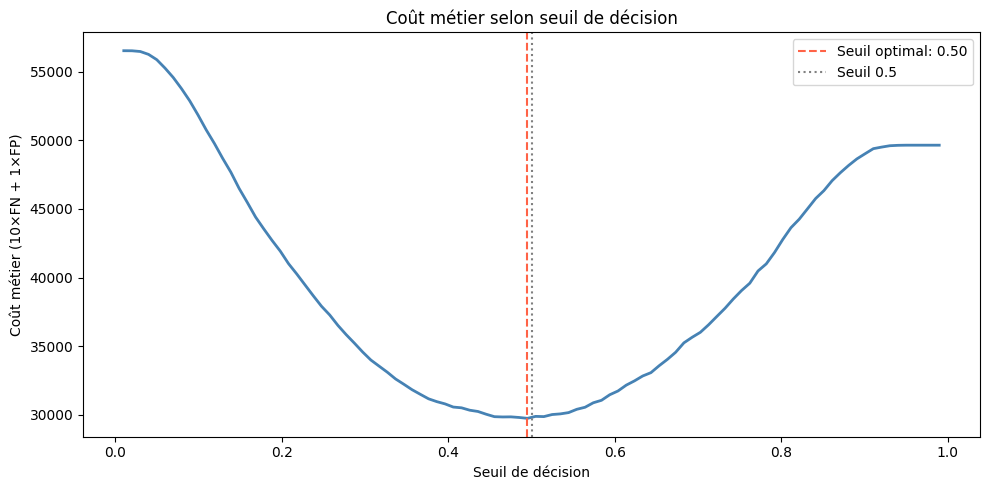

Coût au seuil 0.5: 29735
Coût au seuil optimal 0.50 : 29734
Gain: 1


In [15]:
thresholds = np.linspace(0.01, 0.99, 100)
costs = [error_cost(y_test, test_proba, t) for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue', linewidth=2)
plt.axvline(x=best_t, color='tomato', linestyle='--', label=f'Seuil optimal: {best_t:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Seuil 0.5')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier (10×FN + 1×FP)')
plt.title('Coût métier selon seuil de décision')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Coût au seuil 0.5: {error_cost(y_test, test_proba, 0.5):.0f}')
print(f'Coût au seuil optimal {best_t:.2f} : {cost:.0f}')
print(f'Gain: {error_cost(y_test, test_proba, 0.5) - cost:.0f}')

## Comparaison avec modèle de base


on réentraîne le LightGBM de base avec ses paramètres d'origine et on compare les deux modèles sur le même jeu de test pour vérifier qu'Optuna a bien amélioré les résultats.

In [16]:
lgbm_base_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm_base_model.fit(X_train, y_train)
base_proba = lgbm_base_model.predict_proba(X_test)[:, 1]
base_auc = roc_auc_score(y_test, base_proba)
base_t, base_cost = optimal_threshold(y_test, base_proba)
base_recall = recall_score(y_test, (base_proba >= base_t).astype(int), pos_label=1)

comparaison = pd.DataFrame({
    'Modèle' : ['LightGBM base', 'LightGBM optimisé'],
    'AUC test': [base_auc, auc_test],
    'Coût métier': [base_cost, cost],
    'Seuil optimal': [base_t, best_t],
    'Recall minoritaire': [base_recall, recall],
})
print(comparaison.to_string(index=False))

           Modèle  AUC test  Coût métier  Seuil optimal  Recall minoritaire
    LightGBM base  0.786916        30096       0.534646            0.642296
LightGBM optimisé  0.788380        29734       0.495051            0.669486


## enregistrement dans MLflow et export du modèle final

on enregistre le modèle optimisé dans MLflow et on l'exporte en model.pkl pour l'API.

In [17]:
with mlflow.start_run(run_name='LightGBM_Optimise'):
    mlflow.set_tag('model_type', 'LightGBM')
    mlflow.set_tag('optimisation', 'Optuna')
    mlflow.set_tag('scorer', 'metrique_cout_metier')
    mlflow.log_params(study.best_params)
    mlflow.log_metric('auc_test', auc_test)
    mlflow.log_metric('error_cost', cost)
    mlflow.log_metric('optimal_threshold', best_t)
    mlflow.log_metric('recall_minority', recall)
    mlflow.log_metric('f1_minority', f1)
    mlflow.sklearn.log_model(best_model, artifact_path='model',registered_model_name='credit_scoring_lgbm_final')

# export en .pkl pour l'API
joblib.dump(best_model, 'model.pkl')

2026/03/20 11:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 11:16:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'credit_scoring_lgbm_final' already exists. Creating a new version of this model...
Created version '2' of model 'credit_scoring_lgbm_final'.


['model.pkl']

: 

: 